# EDA
Perform exploratory data analysis (overall data structure, key features, exploring relationship) to inform the data preprocessing and modeling steps

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../1-Data/heart.csv")

# 1. Dataset info

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [3]:
df.describe().T # trans

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


# 2. Class Distribution

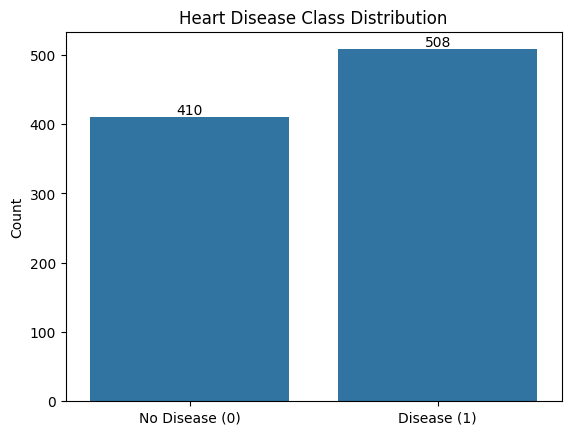

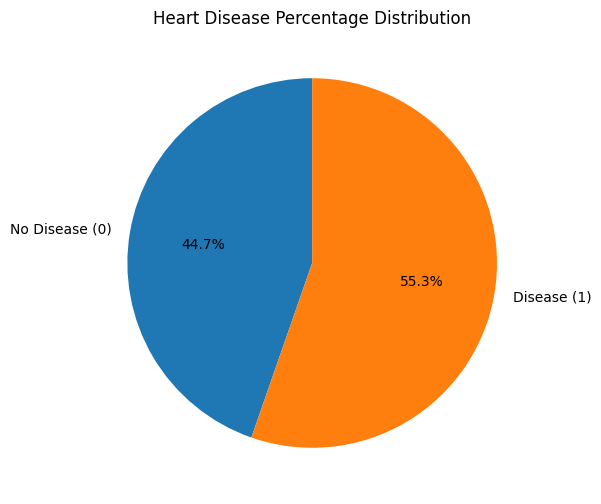

In [18]:
counts = df['HeartDisease'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']

# --- Countplot ---
ax = sns.countplot(data=df, x='HeartDisease')
ax.set(title='Heart Disease Class Distribution', xlabel='', ylabel='Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)

ax.bar_label(ax.containers[0]) 
plt.show()

# --- Pie Chart ---
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Heart Disease Percentage Distribution')
plt.show()

Purpose: Verify class balance before training.  
Insight: ~55% positive class — slight imbalance, no critical action needed.  
Interpretation: Both classes are well-represented. The model won't be trivially biased toward one class.  

# 3. Correlation Heatmap (Numerical Features)

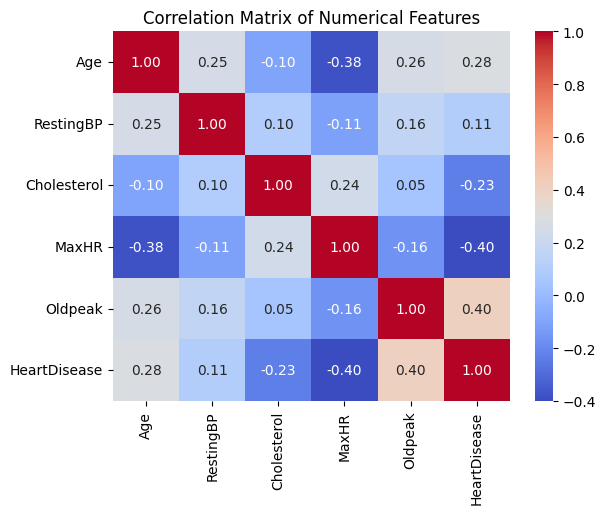

In [20]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Purpose: To identify numerical features that are linearly correlated with the target variable (HeartDisease).  
Insight:   
- MaxHR (-0.40): Shows the strongest negative correlation with HeartDisease.  
- Oldpeak (0.40): Shows the strongest positive correlation with HeartDisease.  
- Age (0.28) and Cholesterol (-0.23): Display moderate linear relationships with the target.  
- RestingBP (0.11): Has the weakest correlation with HeartDisease.  

Interpretaion:  
- Feature Importance: MaxHR and Oldpeak are the strongest numerical predictors for HeartDisease and should be prioritized in modeling.
- Multicollinearity: The highest correlation between any two independent features is between Age and MaxHR (-0.38). Because this is significantly below typical multicollinearity thresholds (±0.70), all numerical features can be safely retained without causing redundancy issues in the model.

# 4. Boxplots: Numerical Features vs Target

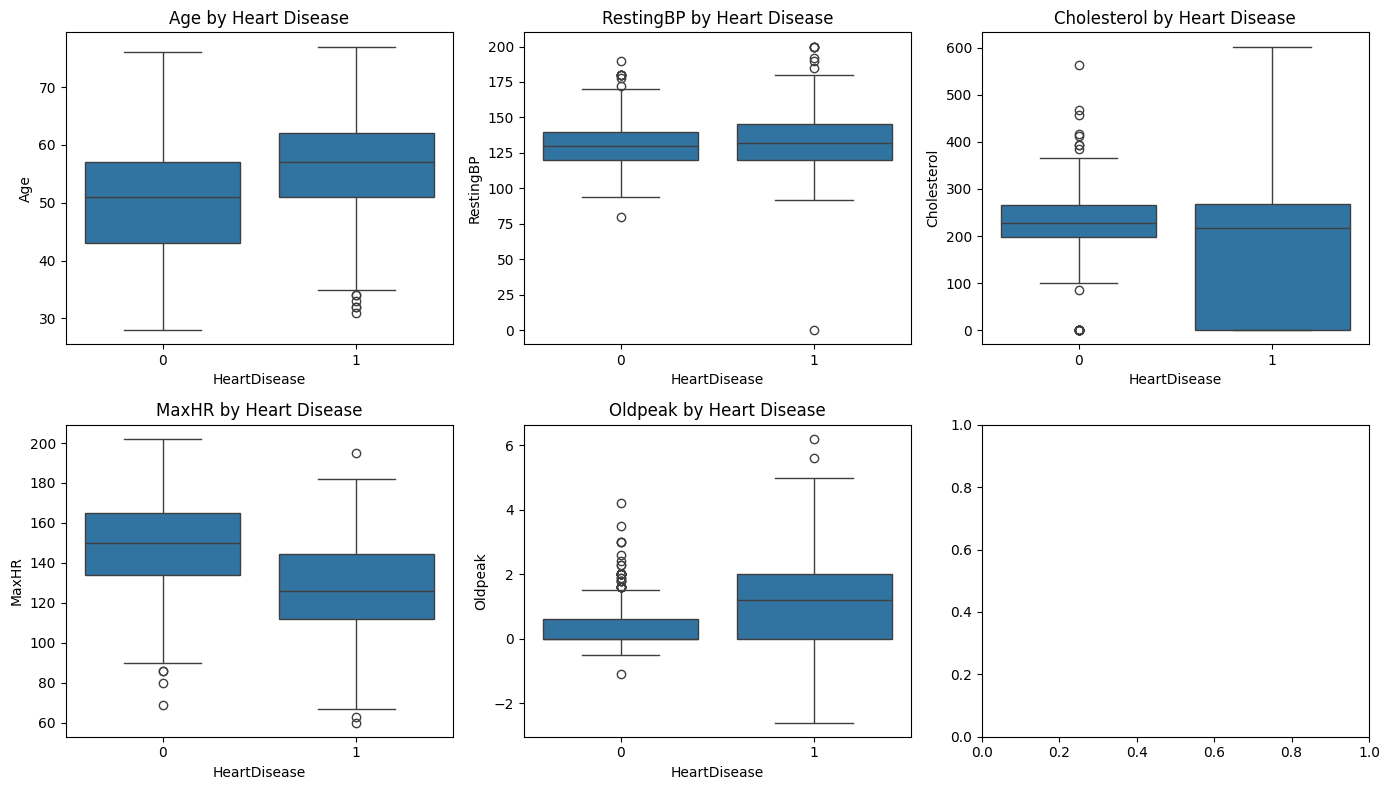

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for i, feat in enumerate(num_features):
    ax = axes[i//3][i%3]
    sns.boxplot(x='HeartDisease', y=feat, data=df, ax=ax)
    ax.set_title(f'{feat} by Heart Disease')
plt.tight_layout()
plt.show()

Purpose:   
To compare the distributions, central tendencies, and spreads of numerical features across the target classes (HeartDisease 0 vs. 1) and to visually identify outliers and data anomalies.  

Insight:   
- Age & Oldpeak: Patients with heart disease (1) have higher median values compared to those without (0).  
- MaxHR: Patients with heart disease (1) have a noticeably lower median maximum heart rate.  
- Data Anomalies: The Cholesterol plot for class 1 shows the lower quartile extending down to 0. RestingBP also shows a data point at exactly 0.  
- Outliers: Significant outliers (circles outside the whiskers) are visible in RestingBP, Cholesterol, MaxHR, and Oldpeak.  

Interpretation:
- Predictive Power: The clear visual separation in the boxes for MaxHR, Oldpeak, and Age confirms these are strong, distinguishing features for predicting heart disease.
- Critical Data Cleaning: The 0 values in Cholesterol and RestingBP are biologically impossible. They indicate missing or erroneous data that must be handled (e.g., imputed or dropped) before training a model.
- Preprocessing Needs: Due to the presence of outliers across multiple features, the data will require careful outlier handling or the use of models robust to outliers (like tree-based algorithms) and appropriate scaling techniques.

# 5. Categorical Feature Analysis

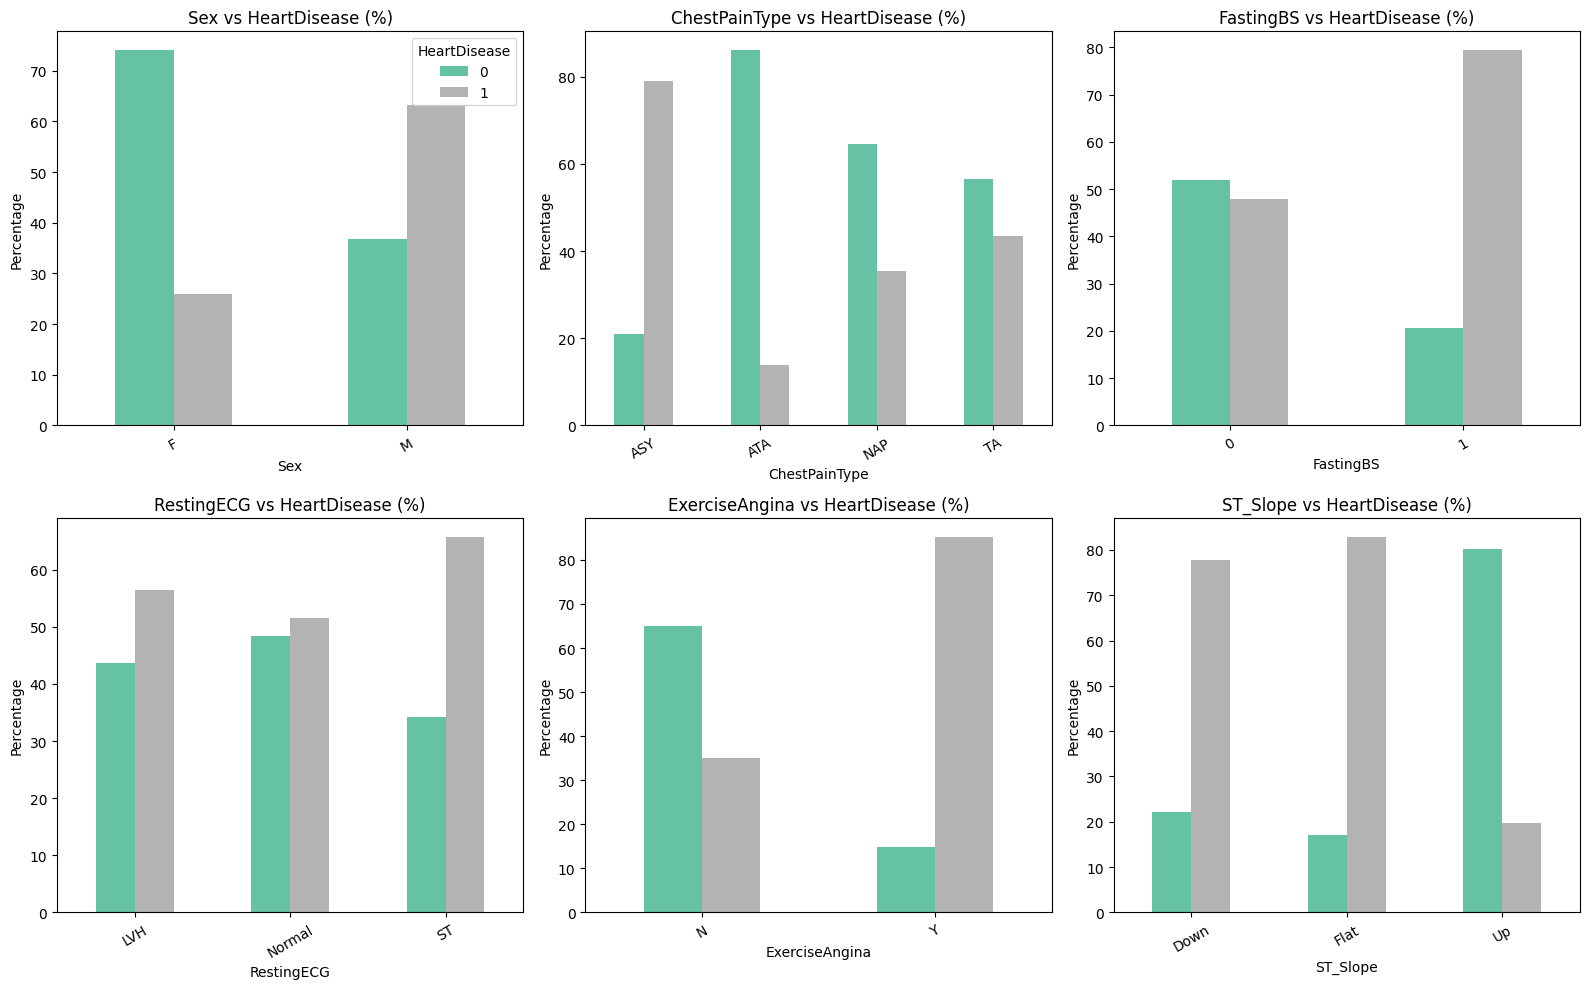

In [29]:
cat_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, feat in enumerate(cat_features):
    ax = axes[i//3][i%3]
    ct = pd.crosstab(df[feat], df['HeartDisease'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='Set2', legend=(i==0))
    ax.set_title(f'{feat} vs HeartDisease (%)')
    ax.set_ylabel('Percentage')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Purpose  
To evaluate the proportional distribution of categorical features across the target classes (HeartDisease 0 vs. 1) to identify which categories are the strongest indicators of the disease.  

Insight  
- Sex: Males (M) exhibit a significantly higher percentage of heart disease compared to females (F).
- ChestPainType: Asymptomatic (ASY) chest pain is overwhelmingly associated with the presence of heart disease, whereas other types lean toward no disease.
- FastingBS: A fasting blood sugar > 120 mg/dl (1) shows a strong correlation with heart disease.
- ExerciseAngina: Patients experiencing exercise-induced angina (Y) have a remarkably high rate of heart disease (~85%).
- ST_Slope: 'Flat' and 'Down' ST slopes are heavily linked to heart disease, while an 'Up' slope is predominantly associated with no disease.  

Interpretation  
- High Predictive Value: Variables like ChestPainType (specifically ASY), ExerciseAngina (Y), and ST_Slope (Flat/Down) show stark visual separations between classes. These will be highly influential features for any classification model.
- Preprocessing Strategy: The strong, non-ordinal relationships within features like ChestPainType and ST_Slope confirm that One-Hot Encoding should be applied before modeling to capture the predictive power of these specific sub-categories effectively.

# 6. Cholesterol Zero-Value Investigation

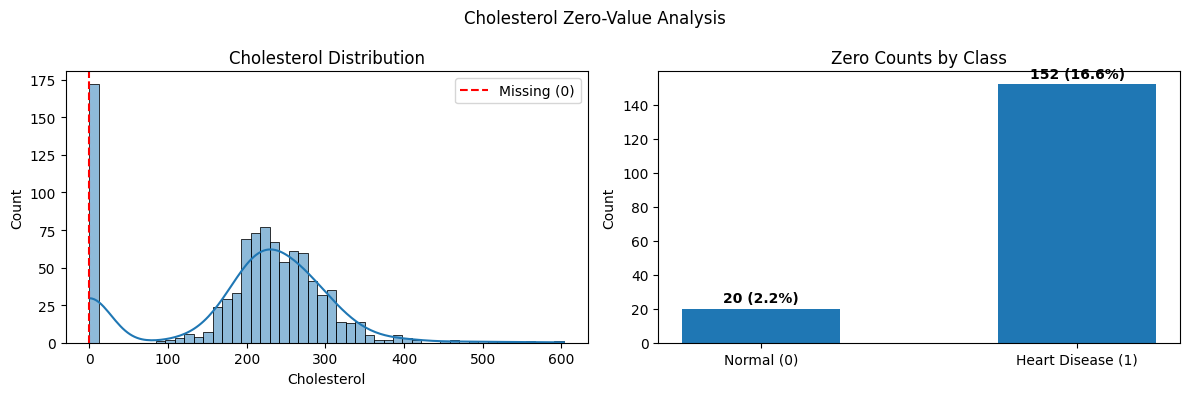

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Cholesterol Zero-Value Analysis")

sns.histplot(df['Cholesterol'], bins=50, kde=True, ax=axes[0])
axes[0].axvline(0, color='red', ls='--', label='Missing (0)')
axes[0].set_title("Cholesterol Distribution")
axes[0].legend()

n_zeros = [20, 152]
total_samples = 918

bars = axes[1].bar(
    ['Normal (0)', 'Heart Disease (1)'],
    n_zeros,
    width=0.5,
)

axes[1].set_title("Zero Counts by Class", )
axes[1].set_ylabel("Count")

for bar in bars:
    height = bar.get_height()
    percent = height / total_samples * 100

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height} ({percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

Purpose  
To evaluate the nature of the zero values in the Cholesterol feature and understand how these potential anomalies relate to the target variable (Heart Disease).

Insight  
- Zeros as Missing Data: The histogram reveals a massive, unnatural spike exactly at 0. Since a human cholesterol level of 0 is biologically impossible, these clearly represent missing values (Nulls/NaNs) that were hardcoded as 0 during data collection.
- Class Imbalance in Missing Data: The bar chart shows these missing values are heavily skewed. There are 152 missing cholesterol readings for patients with heart disease, compared to only 20 for normal patients.

Interpretation  
- Missing At Random (MAR): The 172 records with Cholesterol = 0 are very likely due to the data collection process (the dataset combines data from multiple hospitals, and some hospitals may not have measured cholesterol and therefore recorded a default value of 0), rather than representing patients who actually had a cholesterol level of 0.
- Preprocessing Action Required: We can impute with median.

# 7. MaxHR vs Age Scatter

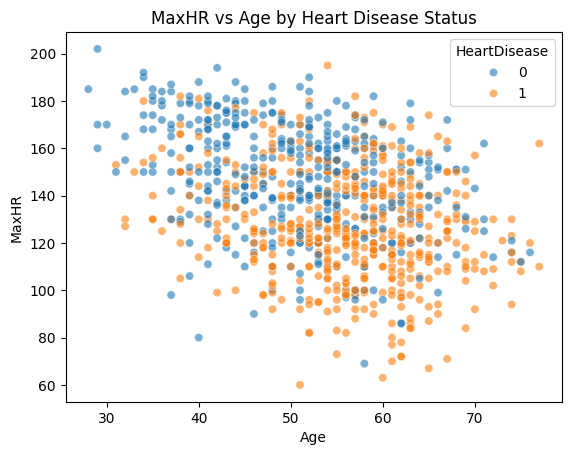

In [34]:
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=df, alpha=0.6)
plt.title('MaxHR vs Age by Heart Disease Status')
plt.show()

Purpose
To visualize the joint relationship between Age and Maximum Heart Rate (MaxHR) and observe how these combined features separate patients with and without heart disease.

Insight
- General Trend: There is a clear negative correlation; as Age increases, MaxHR generally decreases across the entire dataset.
- Class Clustering: Patients without heart disease (0, blue) typically maintain a higher MaxHR for their respective ages, clustering toward the top-left. Patients with heart disease (1, orange) cluster heavily toward the bottom-right, exhibiting both older age and lower MaxHR.

Interpretation
- Combined Predictive Power: Age + MaxHR together strongly separate the classes.
- Limitation of Linear Models: The overlapping middle region suggests that a Logistic Regression (linear boundary) may miss some cases in this overlap zone. This motivates our error analysis section to examine these borderline patients.

# CONCLUSION

The Exploratory Data Analysis confirms that the dataset contains strong predictors for heart disease, particularly MaxHR, Oldpeak, ExerciseAngina, and ST_Slope. The absence of severe multicollinearity among the continuous variables is highly favorable for a Logistic Regression model, as it assumes feature independence. However, because Logistic Regression relies on linear boundaries and distance calculations, it is highly sensitive to outliers and variable scales, making rigorous preprocessing mandatory for the model to converge and perform accurately.

Preprocessing Action Plan

- Anomaly Handling (Missing Data): Impute the 0 values in Cholesterol and RestingBP using the median of their respective non-zero distributions so the algorithm has continuous data to weight.
(reasons:
1. The pattern may reflect dataset collection differences across hospitals 
   rather than true clinical signal.
2. Keeping the pipeline simpler reduces risk of overfitting to dataset-specific artifacts.
3. Median imputation is sufficient for our Logistic Regression baseline.)
- Categorical Encoding: Apply One-Hot Encoding to multi-class variables (ChestPainType, RestingECG, ST_Slope). You must drop one category per feature (e.g., drop_first=True in pandas) to avoid the "dummy variable trap" (perfect multicollinearity), which destabilizes Logistic Regression coefficients. Map binary variables (Sex, ExerciseAngina) to 0 and 1.

- Feature Scaling: Apply StandardScaler to all continuous numerical features. This is critical for Logistic Regression to ensure the optimization algorithm (gradient descent) converges efficiently and that any applied regularization (like L2/Ridge) penalizes all features equally, allowing you to interpret the resulting model coefficients accurately.

# Special for Preprocessing
Do the Cholesterol Distribution in the train_data dataset

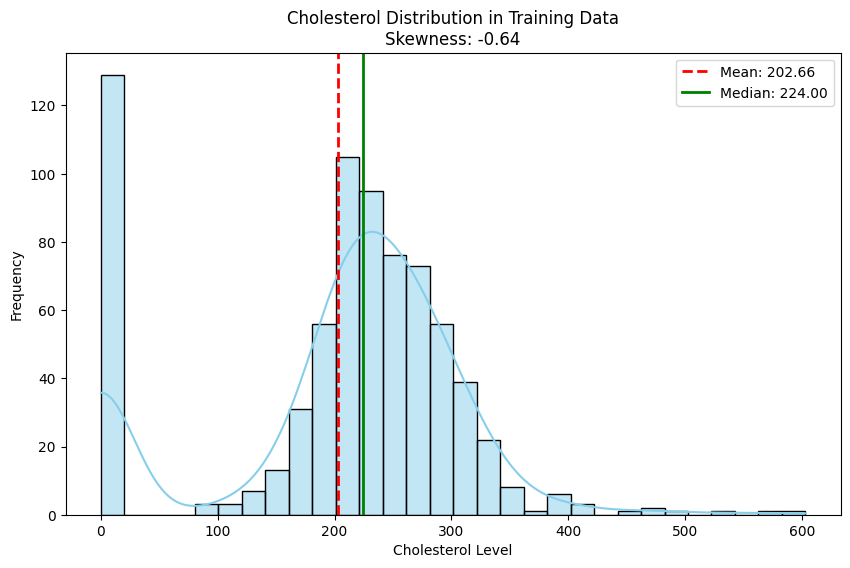

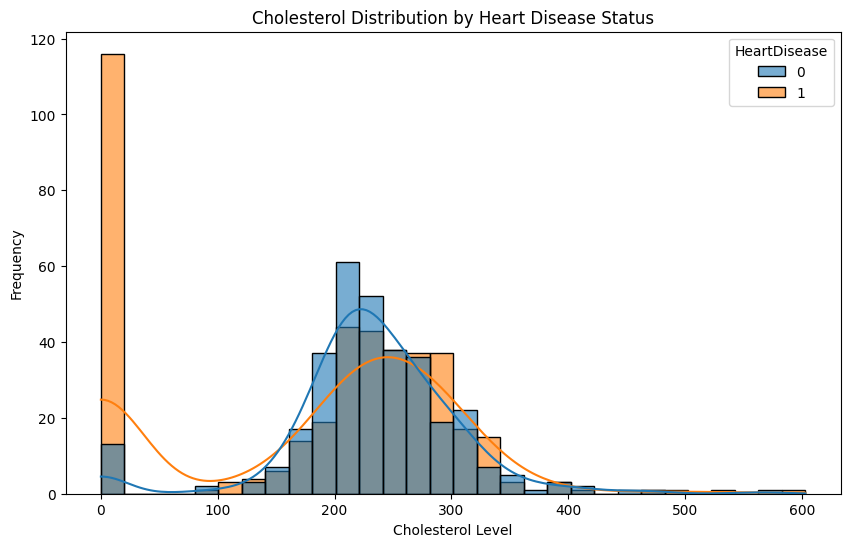

Skewness: -0.64 (>0 indicates right-skewed)
Mean: 202.66
Median: 224.00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

df = pd.read_csv("../1-Data/train_data.csv")

cholesterol_data = df['Cholesterol'].dropna()

mean_val = cholesterol_data.mean()
median_val = cholesterol_data.median()
skewness_val = skew(cholesterol_data)

# Plot 1: Overall Cholesterol Distribution (Checking for Skewness)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Cholesterol', kde=True, color='skyblue', bins=30)

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='solid', linewidth=2, label=f'Median: {median_val:.2f}')

plt.title(f'Cholesterol Distribution in Training Data\nSkewness: {skewness_val:.2f}')
plt.xlabel('Cholesterol Level')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Plot 2: The "Role" of Cholesterol (Distribution grouped by Heart Disease)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', kde=True, bins=30, alpha=0.6)

plt.title('Cholesterol Distribution by Heart Disease Status')
plt.xlabel('Cholesterol Level')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness: {skewness_val:.2f} (>0 indicates right-skewed)")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")